# 5. Analyze Target-Limited Harmonic Trends

This notebook analyzes the trend tables produced by notebook 4.

The goal is to study harmonic change across metadata strata while keeping the relationship between exact n-grams `V_n` and harmonic classes `H_n` visible. Unlike the first draft, this notebook analyzes all configured n-gram lengths, not just `n = 3`.

## Pipeline Role

This notebook analyzes the target-limited trend tables from notebook 4. It is designed to surface strong candidate movements among globally common `H_n` classes.

It should not be read as full vocabulary coverage. Mid-frequency or document-specific harmonic classes are handled by the document-term pipeline in notebooks 7-8.

## Analysis Questions

This notebook starts with five concrete analyses:

1. Decade shifts: which harmonic classes change most over time, for each `n`?
2. Genre specificity: which harmonic classes are unusually concentrated in particular genres, for each `n`?
3. Exact-vs-harmonic divergence: when does an exact progression behave differently from its harmonic class?
4. Representative splits: within one harmonic class, which exact representatives dominate by decade or genre?
5. Visual summaries: which changes are large enough to inspect musically?

In [1]:
from pathlib import Path
import importlib
import os
import sys

CWD = Path.cwd()
ROOT = CWD.parent if (CWD / "utils").exists() else CWD
MPLCONFIGDIR = ROOT / ".matplotlib-cache"
MPLCONFIGDIR.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))

import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd

NOTEBOOK_DIR = ROOT / "notebooks"

# Force this repo's notebook utilities to win over any stale or external `utils` package.
sys.path = [p for p in sys.path if p != str(NOTEBOOK_DIR)]
sys.path.insert(0, str(NOTEBOOK_DIR))
for module_name in list(sys.modules):
    if module_name == "utils" or module_name.startswith("utils."):
        del sys.modules[module_name]

from utils import duckdb_store as ds

ds = importlib.reload(ds)
expected_duckdb_store = (NOTEBOOK_DIR / "utils" / "duckdb_store.py").resolve()
loaded_duckdb_store = Path(ds.__file__).resolve()
assert loaded_duckdb_store == expected_duckdb_store, f"Imported wrong duckdb_store module: {loaded_duckdb_store}; expected {expected_duckdb_store}"

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)


def short_harmonic_label(example: str, harmonic_id: str) -> str:
    """Readable plot label: musical example plus a short stable id suffix."""
    suffix = str(harmonic_id).split("_", 1)[-1][:6]
    return f"{example} ({suffix})"

{
    "python": sys.executable,
    "duckdb_version": duckdb.__version__,
    "duckdb_store": str(loaded_duckdb_store),
}

{'python': '/usr/local/bin/python3',
 'duckdb_version': '1.5.2',
 'duckdb_store': '/Users/juansalinas/Documents/GitHub/harmonic-trends/notebooks/utils/duckdb_store.py'}

In [2]:
DB_PATH = ROOT / "data" / "processed" / "harmonic_trends.duckdb"

NS = tuple(range(3, 9))
MIN_WINDOWS = 50_000
MIN_COUNT = 100
TOP_K_PER_N = 25
PLOT_TOP_K = 12
TRAJECTORY_TOP_K = 6
TARGET_N = 3

assert DB_PATH.exists(), DB_PATH
ROOT, DB_PATH

(PosixPath('/Users/juansalinas/Documents/GitHub/harmonic-trends'),
 PosixPath('/Users/juansalinas/Documents/GitHub/harmonic-trends/data/processed/harmonic_trends.duckdb'))

## Preflight

Notebook 5 expects notebook 4 to have already added the trend tables/views to DuckDB.

In [3]:
required_tables = {
    "exact_ngrams",
    "harmonic_ngrams",
    "trend_exact",
    "trend_harmonic",
    "trend_comparison",
    "trend_stratum_totals",
    "trend_stratum_songs",
}

con = duckdb.connect(str(DB_PATH), read_only=True)
try:
    ds.configure_connection(con)
    tables = set(con.execute("SHOW TABLES").fetchdf()["name"])
    missing = sorted(required_tables - tables)
    assert not missing, f"Missing notebook 4 outputs: {missing}"

    trend_counts = con.execute(
        """
        SELECT 'trend_exact' AS object_name, COUNT(*) AS rows FROM trend_exact
        UNION ALL SELECT 'trend_harmonic', COUNT(*) FROM trend_harmonic
        UNION ALL SELECT 'trend_comparison', COUNT(*) FROM trend_comparison
        UNION ALL SELECT 'trend_stratum_totals', COUNT(*) FROM trend_stratum_totals
        UNION ALL SELECT 'trend_stratum_songs', COUNT(*) FROM trend_stratum_songs
        """
    ).fetchdf()
finally:
    con.close()

trend_counts

,object_name,rows
0,trend_exact,53351
1,trend_harmonic,55839
2,trend_comparison,53351
3,trend_stratum_totals,810
4,trend_stratum_songs,135


## Available Strata

Before looking for trends, inspect how much data each stratum has. Tiny strata can create noisy frequencies.

In [4]:
con = duckdb.connect(str(DB_PATH), read_only=True)
try:
    ds.configure_connection(con)
    stratum_summary = con.execute(
        """
        SELECT
            s.stratum_type,
            COUNT(*) AS n_strata,
            SUM(s.song_count) AS total_song_assignments,
            MIN(s.song_count) AS min_songs,
            MEDIAN(s.song_count) AS median_songs,
            MAX(s.song_count) AS max_songs
        FROM trend_stratum_songs s
        GROUP BY s.stratum_type
        ORDER BY s.stratum_type
        """
    ).fetchdf()

    denominator_summary = con.execute(
        """
        SELECT
            stratum_type,
            n,
            COUNT(*) AS n_strata,
            MIN(total_windows) AS min_windows,
            MEDIAN(total_windows) AS median_windows,
            MAX(total_windows) AS max_windows
        FROM trend_stratum_totals
        GROUP BY stratum_type, n
        ORDER BY stratum_type, n
        """
    ).fetchdf()
finally:
    con.close()

stratum_summary, denominator_summary

(  stratum_type  n_strata  total_song_assignments  min_songs  median_songs  max_songs
 0       decade        14                422181.0          2        5618.0     185492
 1   main_genre        12                352111.0       2814       13690.5      85185
 2         year       109                422181.0          1        1351.0      25894,
    stratum_type  n  n_strata  min_windows  median_windows  max_windows
 0        decade  3        14          116        341007.5     14216707
 1        decade  4        14          114        335393.5     14031272
 2        decade  5        14          112        329782.5     13845874
 3        decade  6        14          110        324173.0     13660551
 4        decade  7        14          108        318574.5     13475344
 5        decade  8        14          106        312981.5     13290284
 6    main_genre  3        12       216106       1120002.0      6596797
 7    main_genre  4        12       213292       1106313.5      6511630
 8    m

## Decade Shifts in H_n for All n

This compares each harmonic class's earliest and latest qualifying decade. The query returns the strongest changes per `n`, not just for one n-gram length.

In [5]:
con = duckdb.connect(str(DB_PATH), read_only=True)
try:
    ds.configure_connection(con)
    decade_shifts_all = con.execute(
        """
        WITH decade_h AS (
            SELECT
                CAST(stratum_value AS INTEGER) AS decade,
                n,
                harmonic_id,
                example_ngram,
                count,
                total_windows,
                frequency
            FROM trend_harmonic
            WHERE stratum_type = 'decade'
              AND n IN (SELECT UNNEST(?))
              AND total_windows >= ?
              AND count >= ?
        ), ranked AS (
            SELECT
                *,
                ROW_NUMBER() OVER (PARTITION BY n, harmonic_id ORDER BY decade ASC) AS first_rank,
                ROW_NUMBER() OVER (PARTITION BY n, harmonic_id ORDER BY decade DESC) AS last_rank
            FROM decade_h
        ), first_last AS (
            SELECT
                f.n,
                f.harmonic_id,
                f.example_ngram AS representative_example_ngram,
                f.decade AS first_decade,
                l.decade AS last_decade,
                f.frequency AS first_frequency,
                l.frequency AS last_frequency,
                l.frequency - f.frequency AS frequency_delta,
                l.frequency / NULLIF(f.frequency, 0) AS frequency_ratio,
                f.count AS first_count,
                l.count AS last_count
            FROM ranked f
            JOIN ranked l USING (n, harmonic_id)
            WHERE f.first_rank = 1
              AND l.last_rank = 1
              AND f.decade < l.decade
        ), ranked_changes AS (
            SELECT
                *,
                ROW_NUMBER() OVER (PARTITION BY n ORDER BY ABS(frequency_delta) DESC, harmonic_id) AS change_rank
            FROM first_last
        )
        SELECT *
        FROM ranked_changes
        WHERE change_rank <= ?
        ORDER BY n, change_rank
        """,
        [list(NS), MIN_WINDOWS, MIN_COUNT, TOP_K_PER_N],
    ).fetchdf()
finally:
    con.close()

decade_shifts_all

,n,harmonic_id,representative_example_ngram,first_decade,last_decade,first_frequency,last_frequency,frequency_delta,frequency_ratio,first_count,last_count,change_rank
0,3,H3_ede3c4f53675bbb0,G C G,1950,2020,0.077958,0.036051,-0.041908,0.462433,7478,150418,1
1,3,H3_35d6bfda85b78e3b,C G C,1950,2020,0.065438,0.031584,-0.033854,0.482654,6277,131781,2
2,3,H3_3569c7a41696606d,C G7 C,1950,2020,0.028481,0.001606,-0.026875,0.056389,2732,6701,3
3,3,H3_aef0281c29774fb7,C G Amin,1950,2020,0.002606,0.025919,0.023313,9.945012,250,108146,4
4,3,H3_cb0f464e362cf3bc,Emin C G,1950,2020,0.001293,0.024304,0.023011,18.800821,124,101406,5
...,...,...,...,...,...,...,...,...,...,...,...,...
145,8,H8_8e587352081d119c,C G D C G D C G,1960,2020,0.002829,0.004716,0.001888,1.667353,1524,18416,21
146,8,H8_f9b96dbe8bf4aee3,Amin G C F Amin G C F,1970,2020,0.000114,0.001996,0.001883,17.578497,128,7794,22
147,8,H8_641a2adee2eee806,D C G D C G D C,1960,2020,0.002663,0.004537,0.001874,1.703553,1435,17717,23
148,8,H8_d1c4462659410d06,G Amin F G Amin F G Amin,1960,2020,0.000258,0.002122,0.001864,8.226210,139,8287,24


## Visualize Decade Shifts

Each panel shows the largest absolute first-to-last decade frequency changes for one `n`. Positive bars increased; negative bars declined. Labels show a representative exact n-gram plus a short suffix of the stable `harmonic_id`.

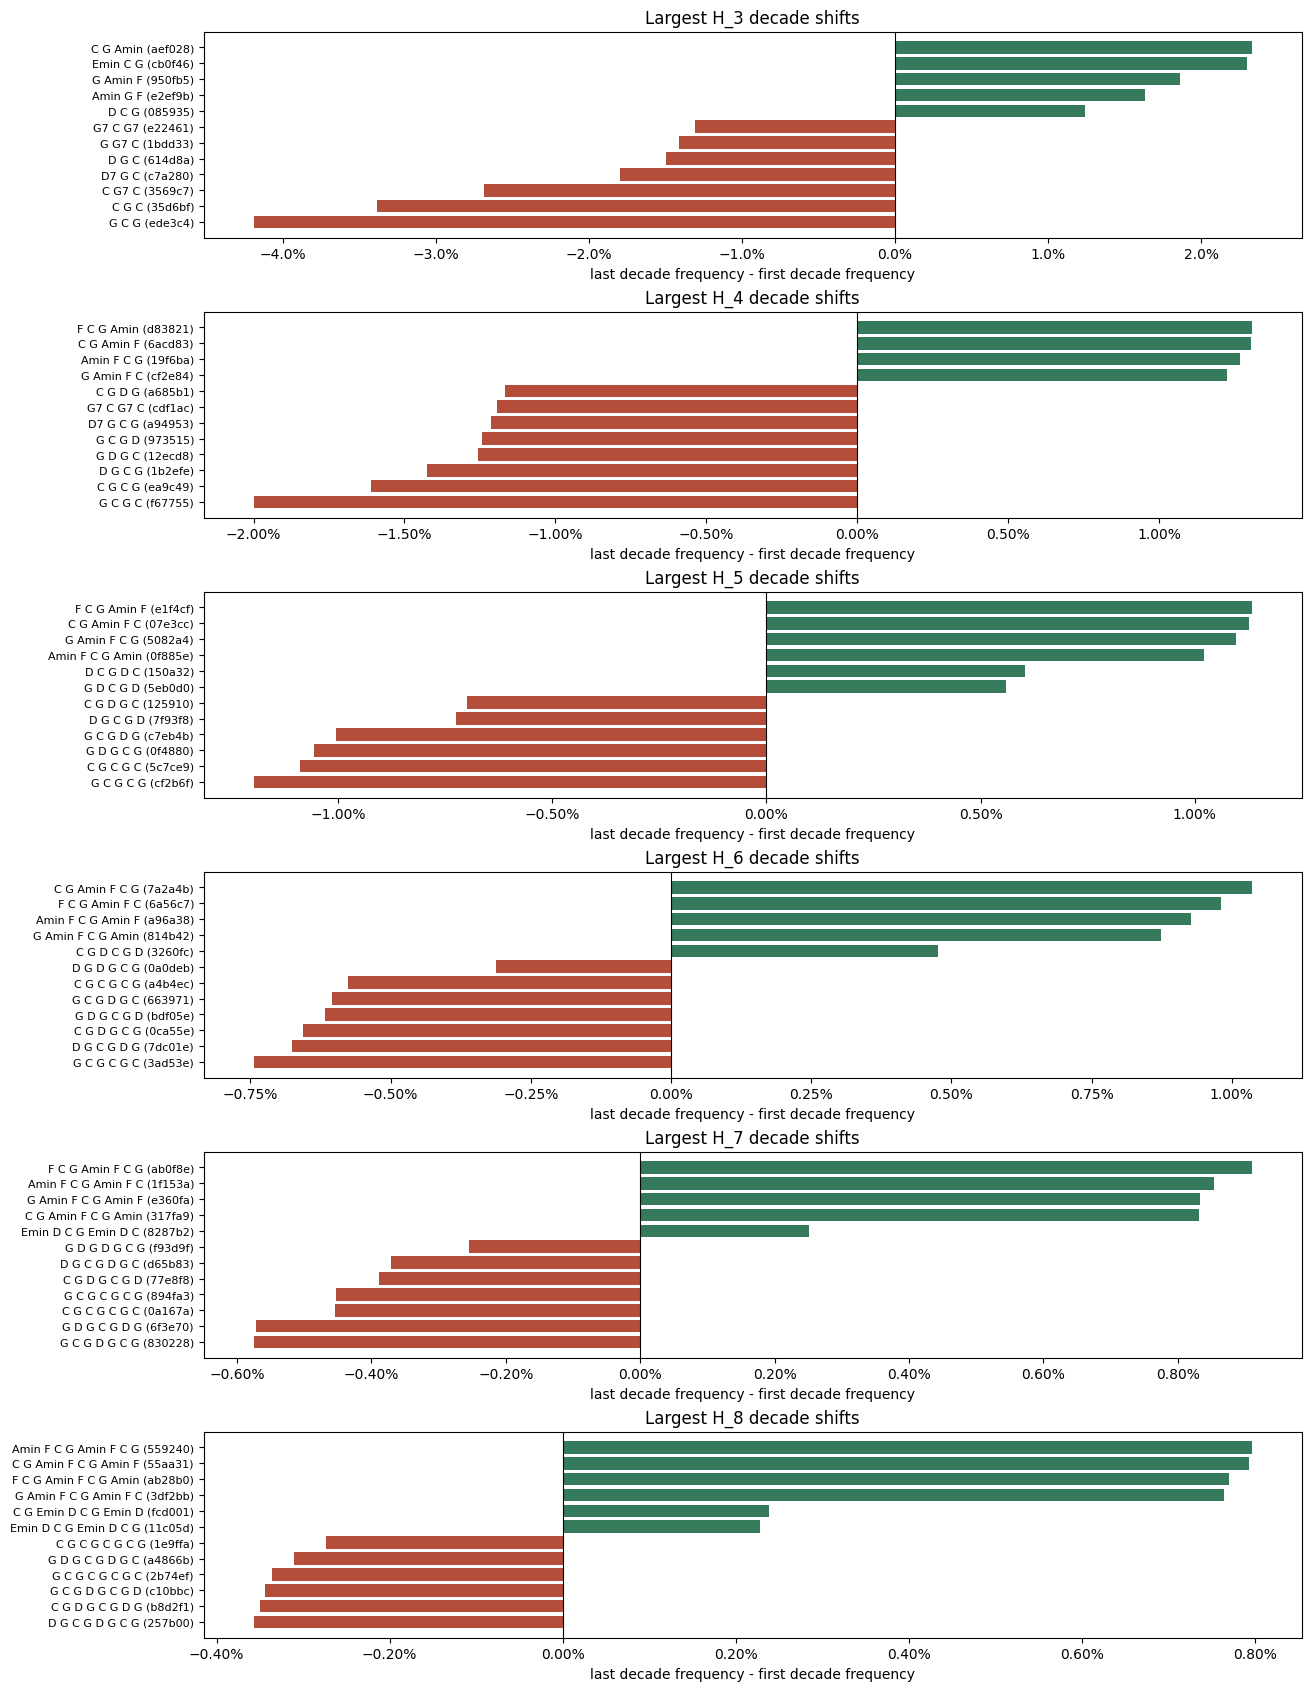

In [6]:
plot_df = decade_shifts_all[decade_shifts_all["change_rank"] <= PLOT_TOP_K].copy()
plot_df["label"] = [
    short_harmonic_label(example, harmonic_id)
    for example, harmonic_id in zip(plot_df["representative_example_ngram"], plot_df["harmonic_id"])
]

fig, axes = plt.subplots(len(NS), 1, figsize=(13, 2.8 * len(NS)), constrained_layout=True)
if len(NS) == 1:
    axes = [axes]

for ax, n in zip(axes, NS):
    sub = plot_df[plot_df["n"] == n].sort_values("frequency_delta")
    colors = ["#b44e3a" if v < 0 else "#347a5b" for v in sub["frequency_delta"]]
    ax.barh(sub["label"], sub["frequency_delta"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_title(f"Largest H_{n} decade shifts")
    ax.set_xlabel("last decade frequency - first decade frequency")
    ax.tick_params(axis="y", labelsize=8)

plt.show()

## Visualize Decade Trajectories

Bar charts show first-to-last change. These line plots show the actual decade trajectories for the largest movers at each `n`, which helps separate smooth trends from endpoint artifacts.

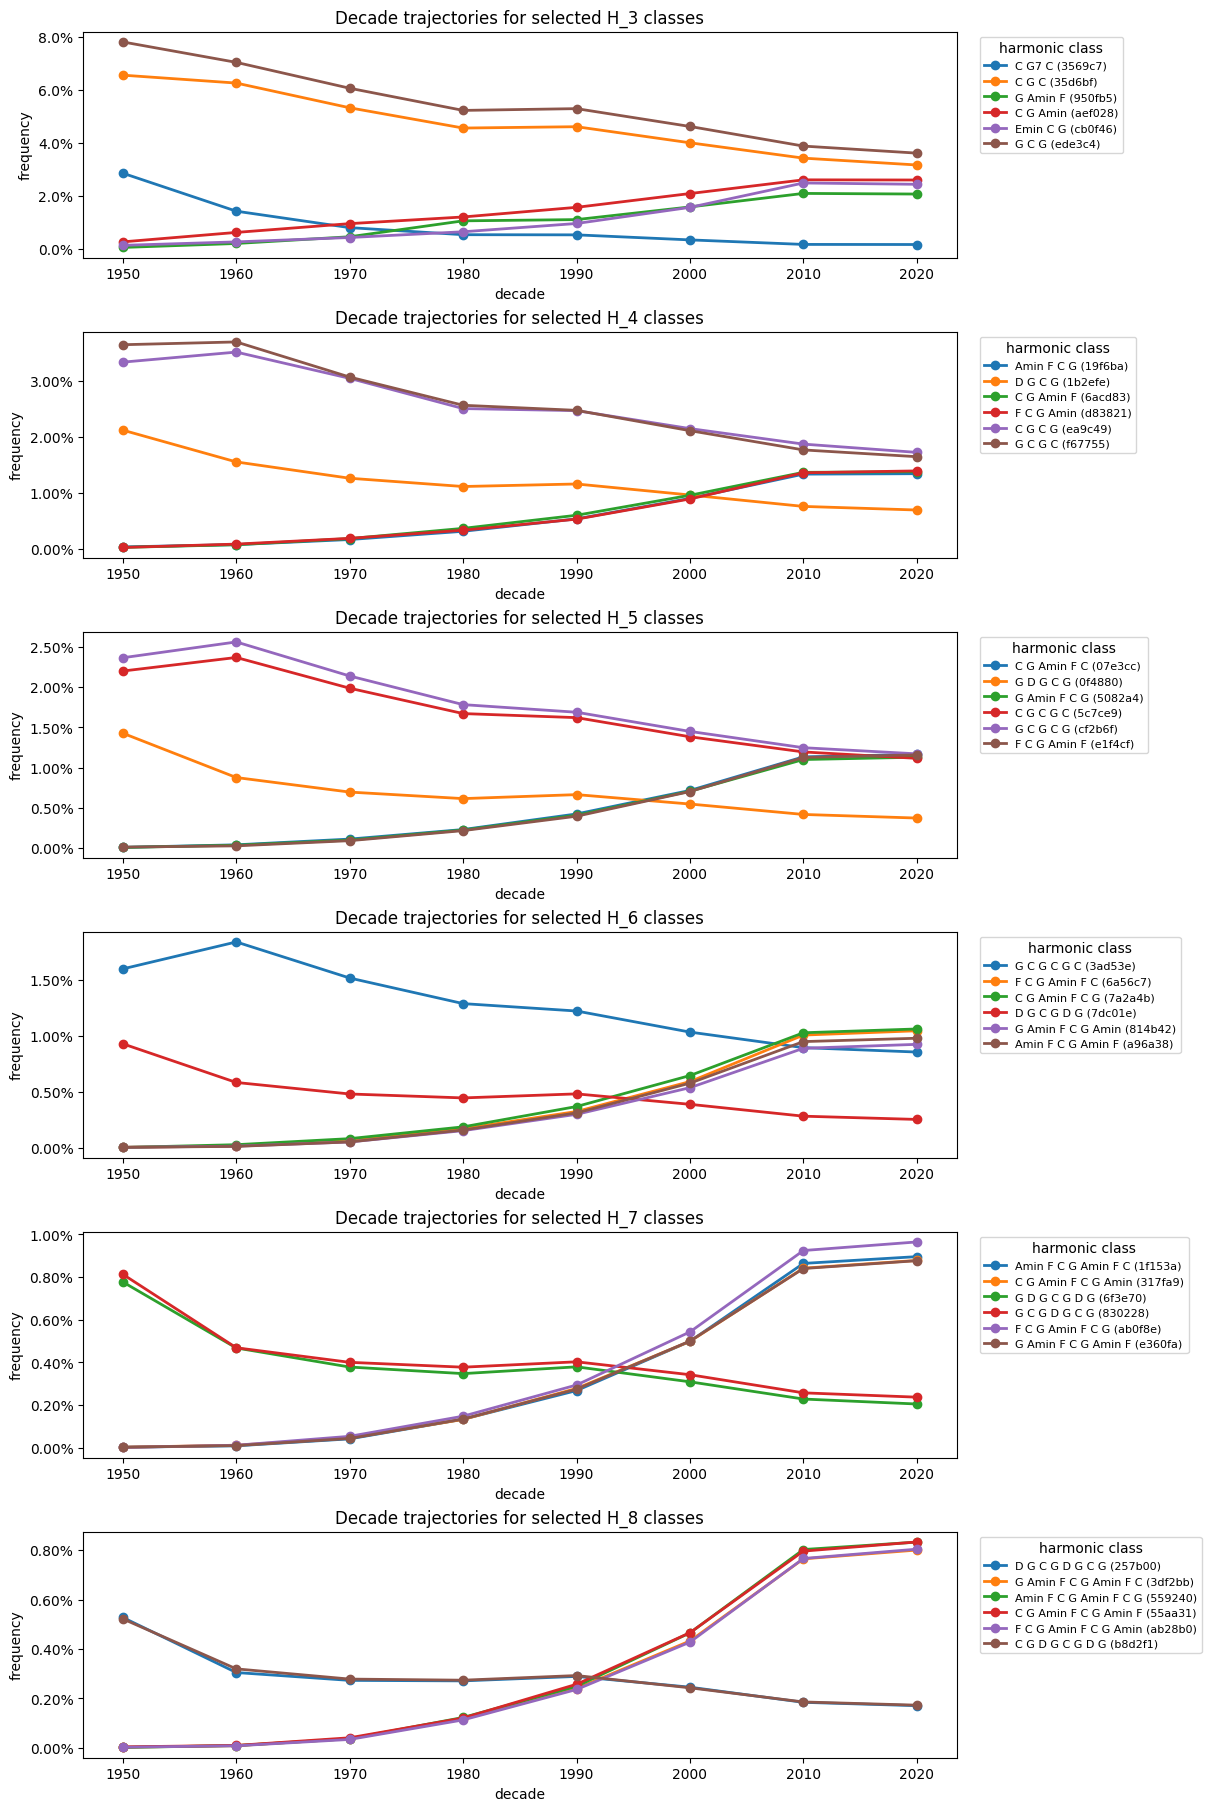

,decade,n,harmonic_id,example_ngram,count,total_windows,frequency
0,1950,3,H3_3569c7a41696606d,C G7 C,2732,95923,0.028481
1,1960,3,H3_3569c7a41696606d,C G7 C,8304,586092,0.014168
2,1970,3,H3_3569c7a41696606d,C G7 C,9622,1207669,0.007967
3,1980,3,H3_3569c7a41696606d,C G7 C,8130,1532130,0.005306
4,1990,3,H3_3569c7a41696606d,C G7 C,15880,3026960,0.005246
...,...,...,...,...,...,...,...
283,1980,8,H8_b8d2f1ee08641402,C G D G C G D G,3926,1435221,0.002735
284,1990,8,H8_b8d2f1ee08641402,C G D G C G D G,8230,2815019,0.002924
285,2000,8,H8_b8d2f1ee08641402,C G D G C G D G,14366,5920071,0.002427
286,2010,8,H8_b8d2f1ee08641402,C G D G C G D G,24639,13290284,0.001854


In [7]:
trajectory_targets = (
    decade_shifts_all
    .assign(abs_delta=lambda df: df["frequency_delta"].abs())
    .sort_values(["n", "abs_delta"], ascending=[True, False])
    .groupby("n", as_index=False)
    .head(TRAJECTORY_TOP_K)
    [["n", "harmonic_id", "representative_example_ngram"]]
)

if trajectory_targets.empty:
    print("No trajectory targets found with current filters.")
    decade_trajectories = trajectory_targets.copy()
else:
    target_pairs = trajectory_targets[["n", "harmonic_id"]].drop_duplicates()
    label_lookup = {
        (row.n, row.harmonic_id): short_harmonic_label(row.representative_example_ngram, row.harmonic_id)
        for row in trajectory_targets.itertuples(index=False)
    }

    con = duckdb.connect(str(DB_PATH), read_only=True)
    try:
        ds.configure_connection(con)
        con.register("target_pairs", target_pairs)
        decade_trajectories = con.execute(
            """
            SELECT
                CAST(h.stratum_value AS INTEGER) AS decade,
                h.n,
                h.harmonic_id,
                h.example_ngram,
                h.count,
                h.total_windows,
                h.frequency
            FROM trend_harmonic h
            JOIN target_pairs t USING (n, harmonic_id)
            WHERE h.stratum_type = 'decade'
              AND h.total_windows >= ?
            ORDER BY h.n, h.harmonic_id, decade
            """,
            [MIN_WINDOWS],
        ).fetchdf()
    finally:
        con.close()

    fig, axes = plt.subplots(len(NS), 1, figsize=(12, 3.0 * len(NS)), constrained_layout=True)
    if len(NS) == 1:
        axes = [axes]

    for ax, n in zip(axes, NS):
        sub_n = decade_trajectories[decade_trajectories["n"] == n]
        if sub_n.empty:
            ax.set_title(f"No qualifying H_{n} trajectories")
            ax.axis("off")
            continue

        for harmonic_id, sub in sub_n.groupby("harmonic_id"):
            ax.plot(
                sub["decade"],
                sub["frequency"],
                marker="o",
                linewidth=2,
                label=label_lookup.get((n, harmonic_id), harmonic_id),
            )
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
        ax.set_title(f"Decade trajectories for selected H_{n} classes")
        ax.set_xlabel("decade")
        ax.set_ylabel("frequency")
        ax.legend(title="harmonic class", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

    plt.show()

decade_trajectories

## Genre-Specific H_n Classes for All n

This compares harmonic-class frequency in one genre against its frequency across all other genres. High lift suggests genre-specific harmonic behavior.

In [8]:
con = duckdb.connect(str(DB_PATH), read_only=True)
try:
    ds.configure_connection(con)
    genre_specific_h_all = con.execute(
        """
        WITH genre_h AS (
            SELECT
                stratum_value AS main_genre,
                n,
                harmonic_id,
                example_ngram,
                count,
                total_windows,
                frequency
            FROM trend_harmonic
            WHERE stratum_type = 'main_genre'
              AND n IN (SELECT UNNEST(?))
              AND total_windows >= ?
              AND count >= ?
        ), totals AS (
            SELECT
                n,
                harmonic_id,
                SUM(count) AS all_genre_count,
                SUM(total_windows) AS all_genre_windows
            FROM genre_h
            GROUP BY n, harmonic_id
        ), scored AS (
            SELECT
                g.main_genre,
                g.n,
                g.harmonic_id,
                g.example_ngram AS representative_example_ngram,
                g.count,
                g.total_windows,
                g.frequency,
                (t.all_genre_count - g.count)::DOUBLE / NULLIF(t.all_genre_windows - g.total_windows, 0) AS other_genre_frequency,
                g.frequency / NULLIF((t.all_genre_count - g.count)::DOUBLE / NULLIF(t.all_genre_windows - g.total_windows, 0), 0) AS genre_lift
            FROM genre_h g
            JOIN totals t USING (n, harmonic_id)
            WHERE t.all_genre_windows > g.total_windows
        ), ranked AS (
            SELECT
                *,
                ROW_NUMBER() OVER (PARTITION BY n ORDER BY genre_lift DESC NULLS LAST, count DESC, harmonic_id) AS lift_rank
            FROM scored
        )
        SELECT *
        FROM ranked
        WHERE lift_rank <= ?
        ORDER BY n, lift_rank
        """,
        [list(NS), MIN_WINDOWS, MIN_COUNT, TOP_K_PER_N],
    ).fetchdf()
finally:
    con.close()

genre_specific_h_all

,main_genre,n,harmonic_id,representative_example_ngram,count,total_windows,frequency,other_genre_frequency,genre_lift,lift_rank
0,country,3,H3_399df86a5aae7301,F C G7,20483,3693669,0.005545,0.000858,6.460602,1
1,country,3,H3_c7a280c94f7b2c52,D7 G C,32125,3693669,0.008697,0.001670,5.209340,2
2,reggae,3,H3_c6c2d59fbc9ff943,Amin Emin Amin,5542,273138,0.020290,0.003929,5.164374,3
3,country,3,H3_3569c7a41696606d,C G7 C,34861,3693669,0.009438,0.001853,5.093976,4
4,reggae,3,H3_50e7ed727fe7c489,Emin Amin Emin,6131,273138,0.022447,0.004618,4.860192,5
...,...,...,...,...,...,...,...,...,...,...
145,electronic,8,H8_77ca8b63b284045b,F Amin C G F Amin C G,557,202052,0.002757,0.000677,4.070596,21
146,electronic,8,H8_7f64acc42494a7f9,C G F Amin C G F Amin,544,202052,0.002692,0.000663,4.061901,22
147,country,8,H8_4dbb95ba0a1df768,C G D G C G C G,5656,3427416,0.001650,0.000408,4.045645,23
148,country,8,H8_b8d2f1ee08641402,C G D G C G D G,20985,3427416,0.006123,0.001550,3.949500,24


## Visualize Genre Lift

This shows the largest genre lifts for each `n`. The x-axis is logarithmic because lift ratios can vary widely. Inspect `count` and `total_windows` before making strong musical claims.

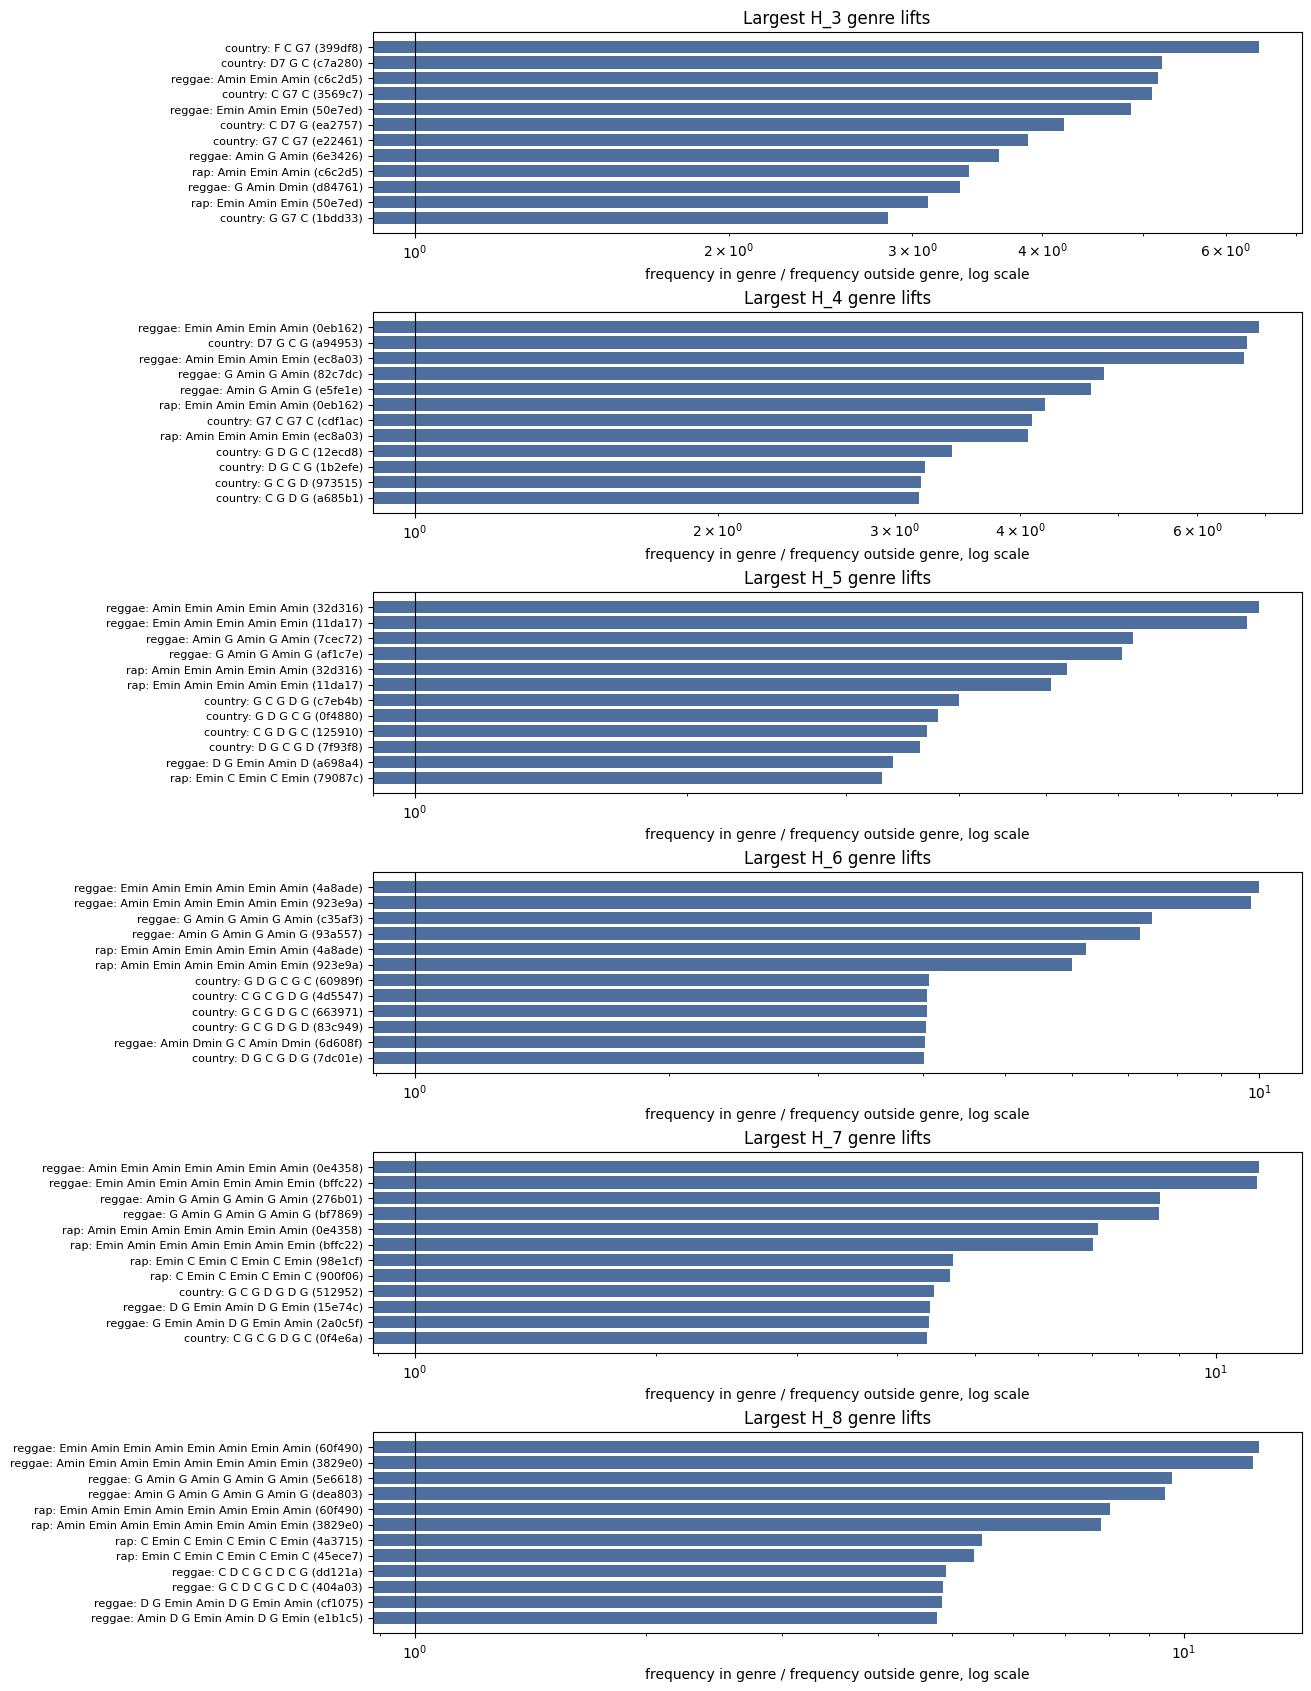

In [9]:
plot_df = genre_specific_h_all[genre_specific_h_all["lift_rank"] <= PLOT_TOP_K].copy()
plot_df["label"] = [
    f"{genre}: {short_harmonic_label(example, harmonic_id)}"
    for genre, example, harmonic_id in zip(
        plot_df["main_genre"],
        plot_df["representative_example_ngram"],
        plot_df["harmonic_id"],
    )
]

fig, axes = plt.subplots(len(NS), 1, figsize=(13, 2.8 * len(NS)), constrained_layout=True)
if len(NS) == 1:
    axes = [axes]

for ax, n in zip(axes, NS):
    sub = plot_df[plot_df["n"] == n].sort_values("genre_lift")
    ax.barh(sub["label"], sub["genre_lift"], color="#4e6f9e")
    ax.axvline(1, color="black", linewidth=0.8)
    ax.set_xscale("log")
    ax.set_title(f"Largest H_{n} genre lifts")
    ax.set_xlabel("frequency in genre / frequency outside genre, log scale")
    ax.tick_params(axis="y", labelsize=8)

plt.show()

## Exact vs Harmonic Divergence for All n

This looks for exact progressions whose frequency is either a large or small share of their harmonic class frequency in a stratum.

The query filters by `MIN_WINDOWS` so sparse years or small strata do not dominate the result.

In [10]:
con = duckdb.connect(str(DB_PATH), read_only=True)
try:
    ds.configure_connection(con)
    exact_harmonic_share_all = con.execute(
        """
        WITH scored AS (
            SELECT
                c.stratum_type,
                c.stratum_value,
                c.n,
                c.exact_ngram_id,
                c.ngram,
                c.harmonic_id,
                c.exact_count,
                c.harmonic_count,
                t.total_windows,
                c.exact_frequency,
                c.harmonic_frequency,
                c.exact_frequency / NULLIF(c.harmonic_frequency, 0) AS exact_share_of_harmonic_frequency
            FROM trend_comparison c
            JOIN trend_stratum_totals t USING (stratum_type, stratum_value, n)
            WHERE c.n IN (SELECT UNNEST(?))
              AND t.total_windows >= ?
              AND c.harmonic_count >= ?
              AND c.exact_count >= ?
              AND c.harmonic_frequency > 0
        ), ranked AS (
            SELECT
                *,
                ROW_NUMBER() OVER (PARTITION BY n ORDER BY exact_share_of_harmonic_frequency DESC, exact_count DESC) AS high_share_rank,
                ROW_NUMBER() OVER (PARTITION BY n ORDER BY exact_share_of_harmonic_frequency ASC, exact_count DESC) AS low_share_rank
            FROM scored
        )
        SELECT *
        FROM ranked
        WHERE high_share_rank <= ? OR low_share_rank <= ?
        ORDER BY n, COALESCE(high_share_rank, low_share_rank)
        """,
        [list(NS), MIN_WINDOWS, MIN_COUNT, MIN_COUNT, TOP_K_PER_N, TOP_K_PER_N],
    ).fetchdf()
finally:
    con.close()

exact_harmonic_high_share_all = (
    exact_harmonic_share_all[exact_harmonic_share_all["high_share_rank"] <= TOP_K_PER_N]
    .sort_values(["n", "high_share_rank"])
    .copy()
)
exact_harmonic_low_share_all = (
    exact_harmonic_share_all[exact_harmonic_share_all["low_share_rank"] <= TOP_K_PER_N]
    .sort_values(["n", "low_share_rank"])
    .copy()
)

exact_harmonic_high_share_all, exact_harmonic_low_share_all

(    stratum_type stratum_value  n      exact_ngram_id                        ngram          harmonic_id  exact_count  harmonic_count  total_windows  \
 0           year          1970  3  3_a5a005e1bea136a3                     Amin G F  H3_e2ef9b9885d3becc          290             553         109991   
 1           year          1972  3  3_03b1260bbd3fc060                     F G Amin  H3_908053190bacc7d7          156             319         109366   
 2           year          1966  3  3_34bd8a7bd4e52cc6                     G Amin C  H3_71b7423cfec44532          107             223          56397   
 3           year          1971  3  3_6ba280f492b5691c                     G D Amin  H3_57848a2f1ddacc15          122             256         100110   
 4           year          1969  3  3_03b1260bbd3fc060                     F G Amin  H3_908053190bacc7d7          129             281          91271   
 ..           ...           ... ..                 ...                          ...     

## Representative Splits for the Top H_n Class at Each n

For each `n`, pick the globally most frequent harmonic class and inspect which exact representatives dominate by decade and genre.

In [11]:
con = duckdb.connect(str(DB_PATH), read_only=True)
try:
    ds.configure_connection(con)
    target_harmonic_ids = con.execute(
        """
        SELECT n, harmonic_id, example_ngram AS representative_example_ngram, count, frequency
        FROM harmonic_ngrams
        WHERE n IN (SELECT UNNEST(?))
        QUALIFY ROW_NUMBER() OVER (PARTITION BY n ORDER BY count DESC, harmonic_id) = 1
        ORDER BY n
        """,
        [list(NS)],
    ).fetchdf()
finally:
    con.close()

target_harmonic_ids

,n,harmonic_id,representative_example_ngram,count,frequency
0,3,H3_ede3c4f53675bbb0,G C G,2203877,0.043525
1,4,H4_ea9c499da62b44ab,C G C G,1007932,0.020177
2,5,H5_cf2b6f96668e19a7,G C G C G,667134,0.013539
3,6,H6_3ad53e41d93f2bea,G C G C G C,467821,0.009627
4,7,H7_894fa3ad732f1fb4,G C G C G C G,357565,0.007462
5,8,H8_55aa31cb16dc163b,C G Amin F C G Amin F,292190,0.006185


In [12]:
con = duckdb.connect(str(DB_PATH), read_only=True)
try:
    ds.configure_connection(con)
    representatives_by_decade_all = con.execute(
        """
        WITH targets AS (
            SELECT n, harmonic_id
            FROM harmonic_ngrams
            WHERE n IN (SELECT UNNEST(?))
            QUALIFY ROW_NUMBER() OVER (PARTITION BY n ORDER BY count DESC, harmonic_id) = 1
        )
        SELECT
            c.n,
            c.stratum_value AS decade,
            c.ngram,
            c.exact_ngram_id,
            c.exact_count,
            c.harmonic_count,
            c.exact_frequency,
            c.harmonic_frequency,
            c.exact_count::DOUBLE / NULLIF(c.harmonic_count, 0) AS exact_count_share_within_H
        FROM trend_comparison c
        JOIN targets t USING (n, harmonic_id)
        WHERE c.stratum_type = 'decade'
          AND c.harmonic_count >= ?
        QUALIFY ROW_NUMBER() OVER (PARTITION BY c.n, c.stratum_value ORDER BY c.exact_count DESC, c.exact_ngram_id) <= 10
        ORDER BY c.n, CAST(decade AS INTEGER), c.exact_count DESC
        """,
        [list(NS), MIN_COUNT],
    ).fetchdf()

    representatives_by_genre_all = con.execute(
        """
        WITH targets AS (
            SELECT n, harmonic_id
            FROM harmonic_ngrams
            WHERE n IN (SELECT UNNEST(?))
            QUALIFY ROW_NUMBER() OVER (PARTITION BY n ORDER BY count DESC, harmonic_id) = 1
        )
        SELECT
            c.n,
            c.stratum_value AS main_genre,
            c.ngram,
            c.exact_ngram_id,
            c.exact_count,
            c.harmonic_count,
            c.exact_frequency,
            c.harmonic_frequency,
            c.exact_count::DOUBLE / NULLIF(c.harmonic_count, 0) AS exact_count_share_within_H
        FROM trend_comparison c
        JOIN targets t USING (n, harmonic_id)
        WHERE c.stratum_type = 'main_genre'
          AND c.harmonic_count >= ?
        QUALIFY ROW_NUMBER() OVER (PARTITION BY c.n, c.stratum_value ORDER BY c.exact_count DESC, c.exact_ngram_id) <= 10
        ORDER BY c.n, main_genre, c.exact_count DESC
        """,
        [list(NS), MIN_COUNT],
    ).fetchdf()
finally:
    con.close()

representatives_by_decade_all, representatives_by_genre_all

(     n decade                    ngram      exact_ngram_id  exact_count  harmonic_count  exact_frequency  harmonic_frequency  exact_count_share_within_H
 0    3   1890                    D G D  3_fe4dbe8dc705a25b           76             135         0.031289            0.055578                    0.562963
 1    3   1890                    G C G  3_ce87d78ae19f8322           29             135         0.011939            0.055578                    0.214815
 2    3   1890                    E A E  3_666a7630422963ab           19             135         0.007822            0.055578                    0.140741
 3    3   1890                    B E B  3_5d0743cc19a9171a            2             135         0.000823            0.055578                    0.014815
 4    3   1920                    G C G  3_ce87d78ae19f8322           35             137         0.010789            0.042232                    0.255474
 ..  ..    ...                      ...                 ...          ...    

## Visualize Representative Splits

This example visualizes exact representatives for the top harmonic class at `TARGET_N`, by decade. Change `TARGET_N` above to inspect another n-gram length.

The chart shows the most common exact representatives and groups the remaining class mass as `Other exact reps`.

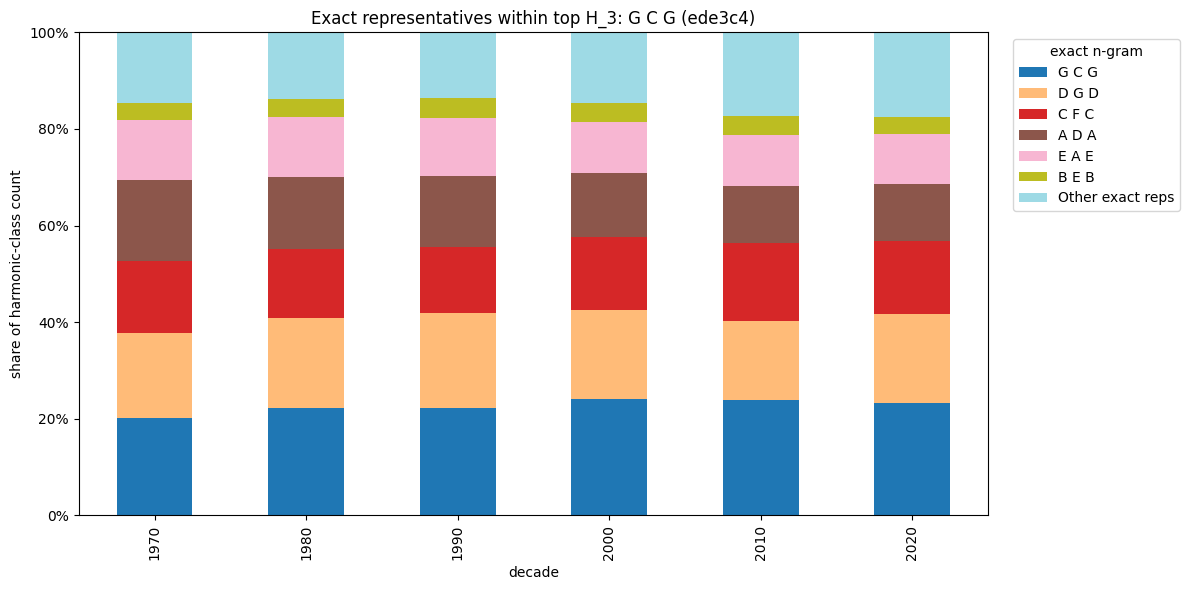

In [13]:
plot_df = representatives_by_decade_all[representatives_by_decade_all["n"] == TARGET_N].copy()

if plot_df.empty:
    print(f"No representative split data found for n={TARGET_N} with current filters.")
else:
    plot_df["decade"] = plot_df["decade"].astype(int)
    latest_decades = sorted(plot_df["decade"].unique())[-6:]
    plot_df = plot_df[plot_df["decade"].isin(latest_decades)]

    pivot_all = (
        plot_df.pivot_table(
            index="decade",
            columns="ngram",
            values="exact_count_share_within_H",
            aggfunc="sum",
            fill_value=0,
        )
    )
    top_cols = pivot_all.sum(axis=0).sort_values(ascending=False).head(8).index
    pivot = pivot_all[top_cols].copy()
    pivot["Other exact reps"] = (1.0 - pivot.sum(axis=1)).clip(lower=0)

    target_row = target_harmonic_ids[target_harmonic_ids["n"] == TARGET_N].iloc[0]
    target_label = short_harmonic_label(
        target_row["representative_example_ngram"],
        target_row["harmonic_id"],
    )

    ax = pivot.plot(kind="bar", stacked=True, figsize=(12, 6), colormap="tab20")
    ax.set_title(f"Exact representatives within top H_{TARGET_N}: {target_label}")
    ax.set_ylabel("share of harmonic-class count")
    ax.set_xlabel("decade")
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.legend(title="exact n-gram", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

## Export Candidate Findings

These are small report-oriented analysis tables, not replacement artifacts for the database. The source data remain the DuckDB trend tables produced by notebook 4.

In [14]:
OUT_DIR = ROOT / "data" / "processed" / "analysis"
OUT_DIR.mkdir(parents=True, exist_ok=True)

paths = {
    "decade_shifts_all": OUT_DIR / "H_all_decade_shifts.csv",
    "genre_specific_h_all": OUT_DIR / "H_all_genre_specificity.csv",
    "exact_harmonic_high_share_all": OUT_DIR / "V_all_exact_harmonic_high_share.csv",
    "exact_harmonic_low_share_all": OUT_DIR / "V_all_exact_harmonic_low_share.csv",
    "target_harmonic_ids": OUT_DIR / "H_all_top_targets.csv",
    "representatives_by_decade_all": OUT_DIR / "H_all_top_representatives_by_decade.csv",
    "representatives_by_genre_all": OUT_DIR / "H_all_top_representatives_by_genre.csv",
}

decade_shifts_all.to_csv(paths["decade_shifts_all"], index=False)
genre_specific_h_all.to_csv(paths["genre_specific_h_all"], index=False)
exact_harmonic_high_share_all.to_csv(paths["exact_harmonic_high_share_all"], index=False)
exact_harmonic_low_share_all.to_csv(paths["exact_harmonic_low_share_all"], index=False)
target_harmonic_ids.to_csv(paths["target_harmonic_ids"], index=False)
representatives_by_decade_all.to_csv(paths["representatives_by_decade_all"], index=False)
representatives_by_genre_all.to_csv(paths["representatives_by_genre_all"], index=False)

paths

{'decade_shifts_all': PosixPath('/Users/juansalinas/Documents/GitHub/harmonic-trends/data/processed/analysis/H_all_decade_shifts.csv'),
 'genre_specific_h_all': PosixPath('/Users/juansalinas/Documents/GitHub/harmonic-trends/data/processed/analysis/H_all_genre_specificity.csv'),
 'exact_harmonic_high_share_all': PosixPath('/Users/juansalinas/Documents/GitHub/harmonic-trends/data/processed/analysis/V_all_exact_harmonic_high_share.csv'),
 'exact_harmonic_low_share_all': PosixPath('/Users/juansalinas/Documents/GitHub/harmonic-trends/data/processed/analysis/V_all_exact_harmonic_low_share.csv'),
 'target_harmonic_ids': PosixPath('/Users/juansalinas/Documents/GitHub/harmonic-trends/data/processed/analysis/H_all_top_targets.csv'),
 'representatives_by_decade_all': PosixPath('/Users/juansalinas/Documents/GitHub/harmonic-trends/data/processed/analysis/H_all_top_representatives_by_decade.csv'),
 'representatives_by_genre_all': PosixPath('/Users/juansalinas/Documents/GitHub/harmonic-trends/data/pr

## Next Directions

Good next extensions:

- Plot trajectories for selected `harmonic_id` classes across years or decades.
- Add confidence intervals or bootstrapped uncertainty for sparse strata.
- Compare distances between harmonic classes once `ngram_distances` is populated.
- Move from top-target trend analysis to exhaustive stratified vocabularies only if a concrete analysis requires it.

## Handoff

The exported candidate trend and representative-split tables are for interpretation in notebook 6.

They remain useful, but they answer a narrower question than notebooks 7-8: what happened to globally common targets? The durable counted data remain in DuckDB.